In [1]:
from pathlib import Path
import sys

sys.path.append(r"../src")
from analysis_pipeline import collect_results, apply_hr_eit_corrections
from clinical_impact import run_clinical_impact_analysis

sys.path.append(r"../visualization")
from ssa_plots import bland_altman_plot

## Saving data

In [2]:
patients = ["002", "004", "005", "006", "009", "010", "011", "012", "014", "015", "016", "017", "018"]

phases = ["preswitch", "t0", "t30", "t60", "t90", "t120", "t150", "t180", "t210"]

fs = 256

sync_base = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\data\test")
output_csv = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\output_df.csv")

In [3]:
df_output, errors = collect_results(
    patients=patients,
    phases=phases,
    sync_base=sync_base,
    fs=fs,
    output_csv=output_csv,
)

if errors:
    print("\nErrors:")
    for err in errors:
        print(err)

OK: patient 002, phase preswitch
OK: patient 002, phase t0
OK: patient 002, phase t30
OK: patient 002, phase t60
OK: patient 002, phase t90
OK: patient 002, phase t120
OK: patient 002, phase t150
OK: patient 002, phase t180
OK: patient 002, phase t210
OK: patient 004, phase preswitch
OK: patient 004, phase t0
OK: patient 004, phase t30
OK: patient 004, phase t60
OK: patient 004, phase t90
OK: patient 004, phase t120
OK: patient 004, phase t150
OK: patient 004, phase t180
OK: patient 004, phase t210
OK: patient 005, phase preswitch
OK: patient 005, phase t0
OK: patient 005, phase t30
OK: patient 005, phase t60
OK: patient 005, phase t90
OK: patient 005, phase t120
OK: patient 005, phase t150
OK: patient 005, phase t180
OK: patient 005, phase t210
OK: patient 006, phase preswitch
OK: patient 006, phase t0
OK: patient 006, phase t30
OK: patient 006, phase t60
OK: patient 006, phase t90
OK: patient 006, phase t120
OK: patient 006, phase t150
OK: patient 006, phase t180
OK: patient 006, pha

## Gecorrigeerde EIT 

In [4]:
hr_eit_corrections_bpm = {
    ("002", "t0"): 108.13,
    ("002", "t30"): 111.99,
    ("002", "t60"): 108.41,
    ("002", "t120"): 109.10,
    ("016", "t0"): 113.22,
    ("016", "t30"): 120.52,
    ("016", "t120"): 128.82,
    ("016", "t150"): 111.63,
    ("016", "t180"): 122.40,
    ("018", "preswitch"): 90.50,
}

output_csv_corrected = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\output_df_HR_EIT_corrected.csv")

df_corrected = apply_hr_eit_corrections(
    df=df_output,
    corrections=hr_eit_corrections_bpm,
    output_csv=output_csv_corrected,
)

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Kaspe\\OneDrive\\Documenten\\TM2\\Code\\outputs\\Final\\output_df_HR_EIT_corrected.csv'

## Bland-Altman plot

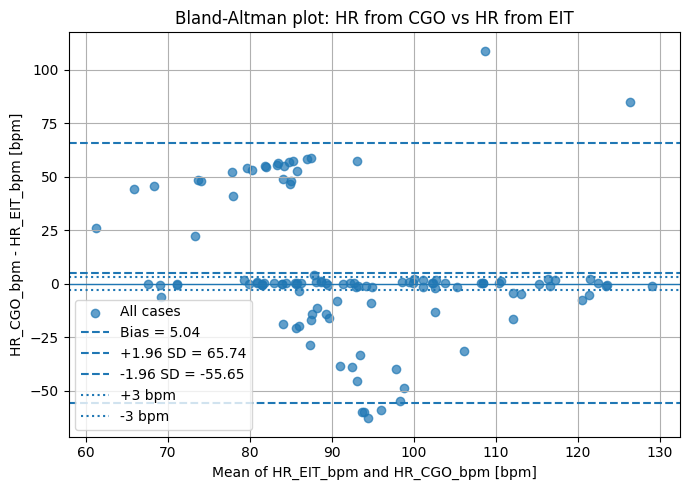

In [5]:
csv_path = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\output_df.csv")
save_path = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\bland_altman_HR_CGO_vs_HR_EIT.png")

bland_altman_plot(
    csv_path=csv_path,
    save_path=save_path,
    col_ref="HR_EIT_bpm",
    col_test="HR_CGO_bpm",
    sep=";",
    title="Bland-Altman plot: HR from CGO vs HR from EIT",
    filter_condition=lambda df: df["chosen_cgo"] == True,
    show_plot=True
)

## Bland-Altman corrected EIT

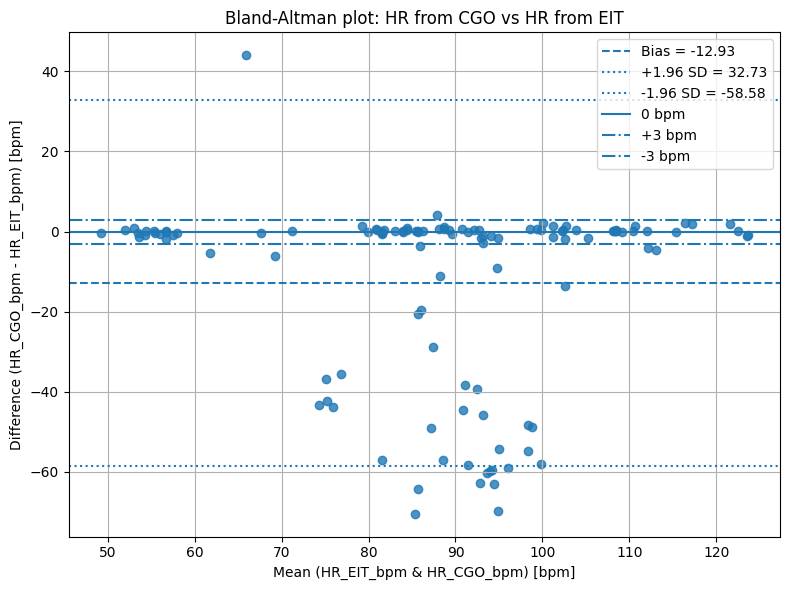

N = 116
Bias: -12.93 bpm
95% LoA: [-58.58, 32.73] bpm


In [ ]:
csv_path = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\output_df_HR_EIT_corrected.csv")
save_path = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\bland_altman_HR_CGO_vs_HR_EIT.png")

bland_altman_plot(
    csv_path=csv_path,
    save_path=save_path,
    col_ref="HR_EIT_bpm",
    col_test="HR_CGO_bpm",
    sep=";",
    title="Bland-Altman plot: HR from CGO vs HR from EIT",
    filter_condition=lambda df: df["chosen_cgo"] == True,
    show_plot=True
)

## Clinical impact

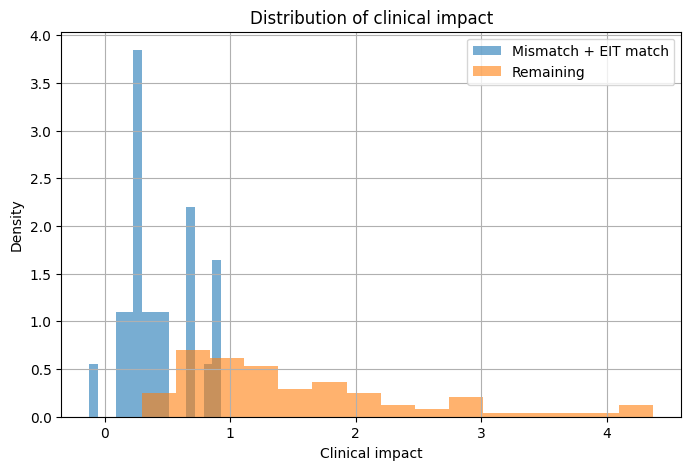

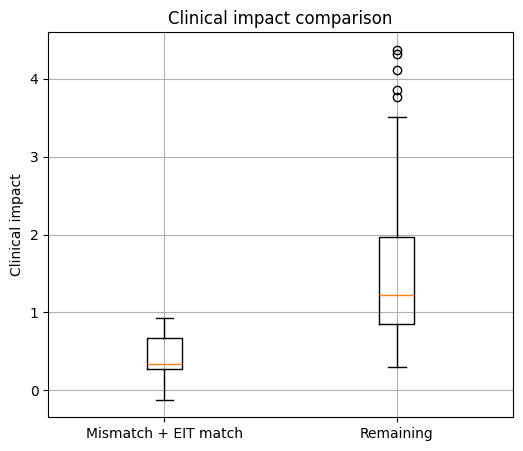

N mismatch cases (with match): 26


In [ ]:
csv_path = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\output_df_HR_EIT_corrected.csv")
output_dir = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final")

overview, summary, group_a, group_b = run_clinical_impact_analysis(
    csv_path=csv_path,
    output_dir=output_dir,
    tolerance_bpm=3,
    hr_diff_threshold=10,
)

import pandas as pd
from pathlib import Path

csv_path = Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\clinical_impact_overview.csv")

df = pd.read_csv(csv_path, sep=";")
n_mismatch = (
    df[df["group"] == "Mismatch + EIT match"]
    [["patient", "phase"]]
    .drop_duplicates()
    .shape[0]
)

print(f"N mismatch cases (with match): {n_mismatch}")

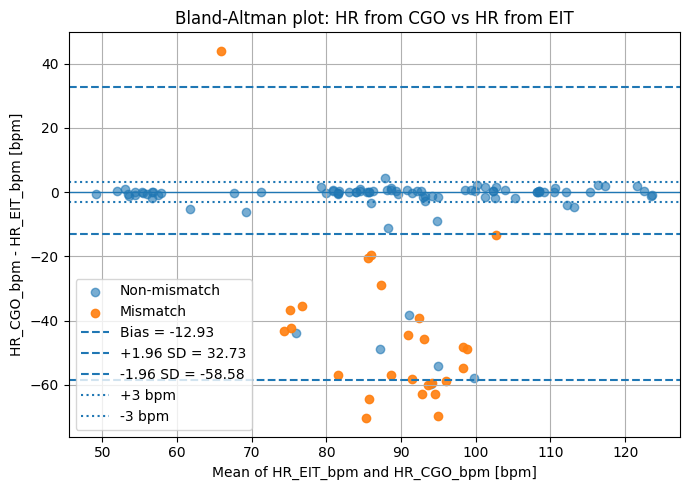

In [ ]:
matched_cases = set(zip(group_a["patient"], group_a["phase"]))

bland_altman_plot(
    csv_path=Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\output_df_HR_EIT_corrected.csv"),
    save_path=Path(r"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\outputs\Final\bland_altman_highlighted.png"),
    col_ref="HR_EIT_bpm",
    col_test="HR_CGO_bpm",
    sep=";",
    title="Bland-Altman plot: HR from CGO vs HR from EIT",
    filter_condition=lambda df: df["chosen_cgo"] == True,
    highlight_condition=lambda df: (
        df.set_index(["patient", "phase"]).index.isin(matched_cases)
    ),
    show_plot=True,
)